In [79]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# CLASSICAL ALGORITHMS

In [80]:
# Searches through an unordered list one by one
def classical_linear_search(items, target):
    queries = 0
    for item in items:
        queries += 1
        if item == target:
            return queries, item
        
    return queries, None

In [81]:
# Searches through a sorted list using binary search
def classical_binary_search(items, target):
    low, high = 0, len(items) - 1
    queries = 0
    while low <= high:
        queries += 1
        mid = (low + high) // 2
        if items[mid] == target:
            return queries, items[mid]
        elif items[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
            
    return queries, None

# QUANTUM ALGORITHM (Grover)

In [82]:
# Oracle that marks the target state by flipping its phase.
def grover_oracle(n_qubits, target):
    qc = QuantumCircuit(n_qubits, name='oracle')

    target_bits = format(target, f'0{n_qubits}b')
    for i, bit in enumerate(reversed(target_bits)):     # qubit 0 = least significant bit
        if bit == '0':
            qc.x(i)

    # Multi-controlled Z: flips the phase of |11...1⟩
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)

    for i, bit in enumerate(reversed(target_bits)):
        if bit == '0':
            qc.x(i)

    return qc

In [83]:
# Grover diffusion operator (reflection about the mean).
def grover_reflection(n_qubits):
    qc = QuantumCircuit(n_qubits, name='reflection')
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc

In [84]:
# Grover search on the Aer simulator. Returns (n_iterations, counts, found, elapsed_time, circuit_depth).
# found = True si la probabilidad de medir el objetivo supera el umbral 1/√N
#         (√N veces más probable que una distribución uniforme)
def grover_search(n_qubits, target, shots=1000):
    N = 2 ** n_qubits
    n_iterations = max(1, int(np.pi / 4 * np.sqrt(N)))  # optimal: π/4 · √N

    oracle     = grover_oracle(n_qubits, target)
    reflection = grover_reflection(n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(reflection, range(n_qubits))

    qc.measure(range(n_qubits), range(n_qubits))

    backend    = AerSimulator()
    transpiled = transpile(qc, backend)
    depth      = transpiled.depth()

    start_time   = time.perf_counter()
    job          = backend.run(transpiled, shots=shots)
    counts       = job.result().get_counts()
    total_time   = time.perf_counter() - start_time

    target_str   = format(target, f'0{n_qubits}b')
    target_prob  = counts.get(target_str, 0) / shots
    found        = target_prob > 1 / np.sqrt(N)

    return n_iterations, counts, found, total_time, depth

In [85]:
# Grover search on real IBM hardware.
#   target_prob : fraction of shots measuring the target (noise indicator, 1.0 = ideal)
#   depth_real  : transpiled circuit depth on the actual hardware topology
#   found       : True if target_prob > 1/√N  (√N times above uniform baseline)
def grover_search_real(n_qubits, target, shots=1000):
    N = 2 ** n_qubits
    n_iterations = max(1, int(np.pi / 4 * np.sqrt(N)))

    oracle     = grover_oracle(n_qubits, target)
    reflection = grover_reflection(n_qubits)

    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(n_iterations):
        qc.append(oracle, range(n_qubits))
        qc.append(reflection, range(n_qubits))

    qc.measure(range(n_qubits), range(n_qubits))

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n_qubits)
    print(f"  Using backend: {backend.name}  ({n_qubits} qubits needed)")

    pm         = generate_preset_pass_manager(backend=backend, optimization_level=1)
    transpiled = pm.run(qc)
    depth_real = transpiled.depth()

    sampler = Sampler(backend)
    job     = sampler.run([transpiled], shots=shots)

    print(f"  Job ID: {job.job_id()}")
    while True:
        status    = job.status()
        queue_pos = backend.status().pending_jobs
        if queue_pos is not None:
            print(f"  Status: {status} | Queue position: {queue_pos}", end='\r')
        else:
            print(f"  Status: {status}", end='\r')
        if status in ('DONE', 'CANCELLED', 'ERROR'):
            print()
            break
        time.sleep(10)

    result      = job.result()
    counts      = result[0].data.c.get_counts()
    target_str  = format(target, f'0{n_qubits}b')
    target_prob = counts.get(target_str, 0) / shots
    found       = target_prob > 1 / np.sqrt(N)

    return n_iterations, counts, found, backend.name, target_prob, depth_real

# RUN COMPARISON

Real hardware is only run for n ≤ 5 (up to 32-element searches).

Beyond n = 5, the transpiled circuit depth grows rapidly because multi-controlled gates (MCX) decompose into many 2-qubit CNOT gates. The resulting circuit exceeds the coherence time of current IBM hardware, so the error rate becomes too high to produce meaningful results. Larger sizes are covered by simulation only.

In [86]:
qubit_range = range(2, 12)
results = {
    'n_qubits':            [],
    'N':                   [],
    'linear_queries':      [],
    'binary_queries':      [],
    'grover_iters':        [],
    'grover_correct':      [],   # True if simulated target_prob > 1/√N
    'grover_real_correct': [],   # True if real target_prob > 1/√N
    'grover_real_prob':    [],   # fraction of shots measuring the target
    'grover_real_ran':     [],   # True if this case was run on real hardware
    'circuit_depth_sim':   [],   # transpiled depth on AerSimulator
    'circuit_depth_real':  [],   # transpiled depth on IBM hardware (n≤5 only)
}

RUNS = 10  # Average over this many runs (query counts vary with shuffle order)

for n in qubit_range:
    N = 2 ** n
    target = random.randint(0, N - 1)
    items_unordered = list(range(N))
    random.shuffle(items_unordered)
    items_ordered = sorted(items_unordered)

    print(f"n={n}, N={N}, target={target}")

    # Linear search — averaged because query count depends on shuffle order
    lin_queries_total = 0
    for _ in range(RUNS):
        random.shuffle(items_unordered)
        queries, _ = classical_linear_search(items_unordered, target)
        lin_queries_total += queries

    # Binary search — deterministic, RUNS for consistency
    bin_queries_total = 0
    for _ in range(RUNS):
        queries, _ = classical_binary_search(items_ordered, target)
        bin_queries_total += queries

    # Simulated Grover — single run (query count is deterministic)
    n_iters, counts, correct, _, depth_sim = grover_search(n, target, shots=1000)

    # Real Grover (only for n ≤ 5)
    if n <= 5:
        _, _, correct_real, _, prob_real, depth_real = grover_search_real(n, target, shots=1000)
        results['grover_real_correct'].append(correct_real)
        results['grover_real_prob'].append(prob_real)
        results['grover_real_ran'].append(True)
        results['circuit_depth_real'].append(depth_real)
    else:
        results['grover_real_correct'].append(None)
        results['grover_real_prob'].append(None)
        results['grover_real_ran'].append(False)
        results['circuit_depth_real'].append(None)

    results['n_qubits'].append(n)
    results['N'].append(N)
    results['linear_queries'].append(lin_queries_total / RUNS)
    results['binary_queries'].append(bin_queries_total / RUNS)
    results['grover_iters'].append(n_iters)
    results['grover_correct'].append(correct)
    results['circuit_depth_sim'].append(depth_sim)

n=2, N=4, target=0
  Using backend: ibm_fez  (2 qubits needed)
  Job ID: d7kjvt24lglc73fviaq0
  Status: DONE | Queue position: 0 1
n=3, N=8, target=2
  Using backend: ibm_kingston  (3 qubits needed)
  Job ID: d7kk01q8ui0s73b5bjsg
  Status: DONE | Queue position: 0 0
n=4, N=16, target=9
  Using backend: ibm_fez  (4 qubits needed)
  Job ID: d7kk070e7usc73f4tda0
  Status: DONE | Queue position: 0 1
n=5, N=32, target=10
  Using backend: ibm_fez  (5 qubits needed)
  Job ID: d7kk0c8e7usc73f4tdhg
  Status: DONE | Queue position: 0 2
n=6, N=64, target=44
n=7, N=128, target=83
n=8, N=256, target=85
n=9, N=512, target=271
n=10, N=1024, target=324
n=11, N=2048, target=1689


# PLOT 1 — Queries / Iterations

**Nota sobre los modelos de computación comparados:**

| Algoritmo | Modelo | Requisito |
|-----------|--------|-----------|
| Búsqueda lineal | RAM — acceso arbitrario | Lista desordenada |
| Búsqueda binaria | RAM — acceso arbitrario | Lista **ordenada** |
| Grover | Oráculo — solo evalúa si un elemento es el objetivo | Sin estructura interna |

La comparación directa entre Grover y la búsqueda binaria **no es estrictamente justa**: la binaria explota la estructura ordenada de los datos, algo que Grover no puede hacer por diseño. La ventaja cuántica real de Grover es sobre la **búsqueda lineal** en espacios desordenados (O(N) → O(√N)). La búsqueda binaria se incluye como referencia del mejor caso clásico posible bajo un modelo más favorable.

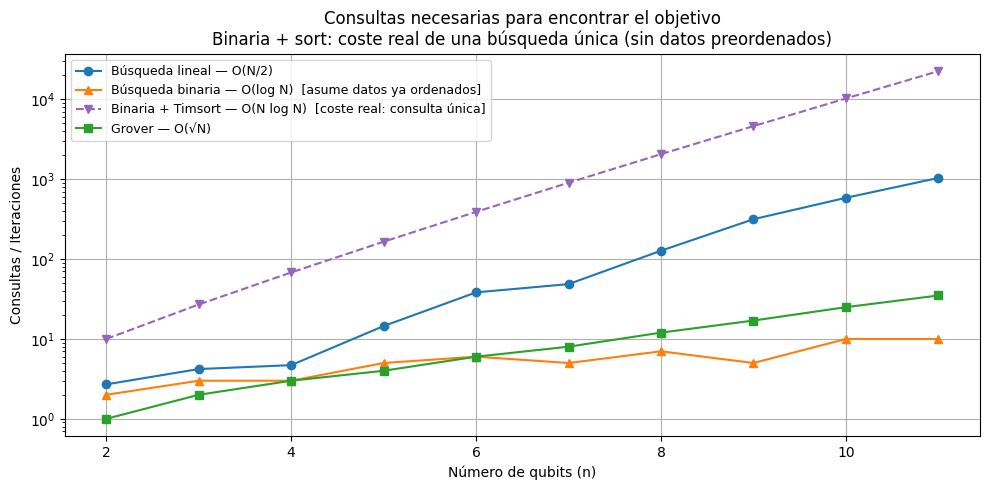

In [87]:
binary_sort_queries = [(results['N'][i] + 1) * np.log2(results['N'][i])
                       for i in range(len(results['n_qubits']))]

plt.figure(figsize=(10, 5))
plt.plot(results['n_qubits'], results['linear_queries'],  'o-',  label='Búsqueda lineal — O(N/2)')
plt.plot(results['n_qubits'], results['binary_queries'],  '^-',  label='Búsqueda binaria — O(log N)  [asume datos ya ordenados]')
plt.plot(results['n_qubits'], binary_sort_queries,        'v--', color='tab:purple',
         label='Binaria + Timsort — O(N log N)  [coste real: consulta única]')
plt.plot(results['n_qubits'], results['grover_iters'],    's-',  label='Grover — O(√N)')
plt.xlabel('Número de qubits (n)')
plt.ylabel('Consultas / Iteraciones')
plt.title('Consultas necesarias para encontrar el objetivo\nBinaria + sort: coste real de una búsqueda única (sin datos preordenados)')
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

# PLOT 2 — Speedup relativo frente a búsqueda lineal

Se muestra cuántas veces más rápido es Grover que los algoritmos clásicos en términos de consultas al oráculo.

- **Speedup teórico vs lineal**: (N/2) / (π/4·√N) = 2/π·√N — crece indefinidamente con N.
- **Speedup medido vs lineal (simulado)**: ratio empírico entre consultas lineales e iteraciones de Grover.
- **Speedup vs binaria (sin sort)**: Grover pierde — binary search O(log N) siempre requiere menos consultas que Grover O(√N) para N grande.
- **Speedup vs binaria + Timsort**: coste real de una búsqueda única sin datos preordenados — aquí Grover gana hasta que se acumula suficiente número de búsquedas para amortizar el sort.
- **Speedup efectivo real IBM**: corregido por probabilidad de éxito en hardware ruidoso.

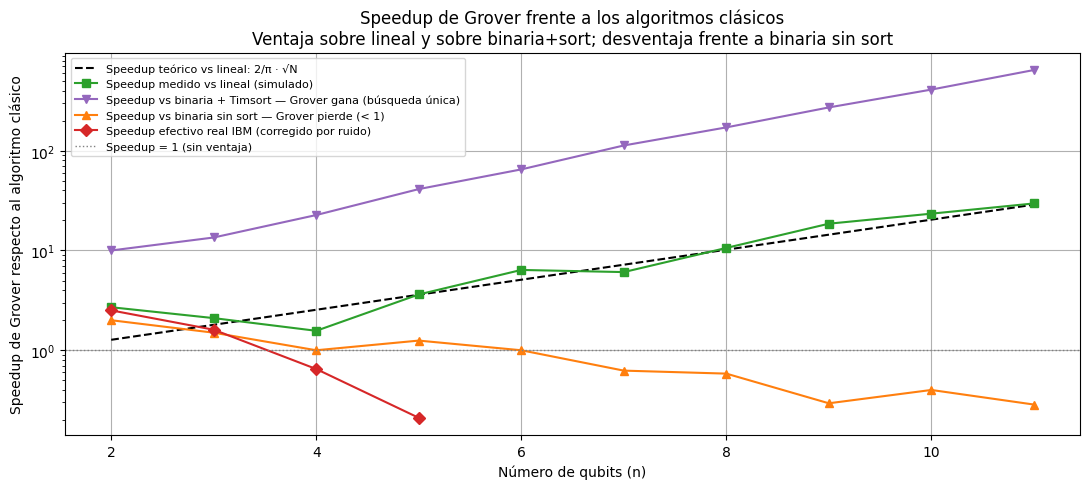

In [88]:
binary_sort_queries  = [(results['N'][i] + 1) * np.log2(results['N'][i])
                        for i in range(len(results['n_qubits']))]

theoretical_speedup      = [2 / np.pi * np.sqrt(2**n) for n in results['n_qubits']]
measured_speedup         = [results['linear_queries'][i] / results['grover_iters'][i]
                             for i in range(len(results['n_qubits']))]
vs_binary_speedup        = [results['binary_queries'][i] / results['grover_iters'][i]
                             for i in range(len(results['n_qubits']))]
vs_binary_sort_speedup   = [binary_sort_queries[i] / results['grover_iters'][i]
                             for i in range(len(results['n_qubits']))]

real_idx         = [i for i in range(len(results['n_qubits'])) if results['grover_real_ran'][i]]
real_n           = [results['n_qubits'][i] for i in real_idx]
real_speedup_eff = [
    results['linear_queries'][i] / (results['grover_iters'][i] / results['grover_real_prob'][i])
    for i in real_idx
]

plt.figure(figsize=(11, 5))
plt.plot(results['n_qubits'], theoretical_speedup,    'k--', label='Speedup teórico vs lineal: 2/π · √N')
plt.plot(results['n_qubits'], measured_speedup,       's-',  color='tab:green',  label='Speedup medido vs lineal (simulado)')
plt.plot(results['n_qubits'], vs_binary_sort_speedup, 'v-',  color='tab:purple', label='Speedup vs binaria + Timsort — Grover gana (búsqueda única)')
plt.plot(results['n_qubits'], vs_binary_speedup,      '^-',  color='tab:orange', label='Speedup vs binaria sin sort — Grover pierde (< 1)')
plt.plot(real_n, real_speedup_eff,                    'D-',  color='tab:red',    label='Speedup efectivo real IBM (corregido por ruido)')
plt.axhline(1, color='gray', linestyle=':', linewidth=1, label='Speedup = 1 (sin ventaja)')

plt.xlabel('Número de qubits (n)')
plt.ylabel('Speedup de Grover respecto al algoritmo clásico')
plt.title('Speedup de Grover frente a los algoritmos clásicos\nVentaja sobre lineal y sobre binaria+sort; desventaja frente a binaria sin sort')
plt.yscale('log')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

# PLOT 2b — Break-even: ¿a partir de cuántas búsquedas la binaria amortiza el sort?

Una vez ordenados los datos, cada búsqueda adicional cuesta solo O(log N). La pregunta es: ¿cuántas búsquedas hacen falta para que el coste total de *sort + k × binary* sea menor que el de *k × Grover* o *k × lineal*?

- **Break-even vs Grover**: `k = N·log₂N / (π/4·√N − log₂N)`. Solo existe cuando Grover necesita más iteraciones que la binaria sin sort (n ≥ 7 aprox.).
- **Break-even vs lineal**: `k = N·log₂N / (N/2 − log₂N)`. Muy pequeño — basta con unas pocas decenas de búsquedas.

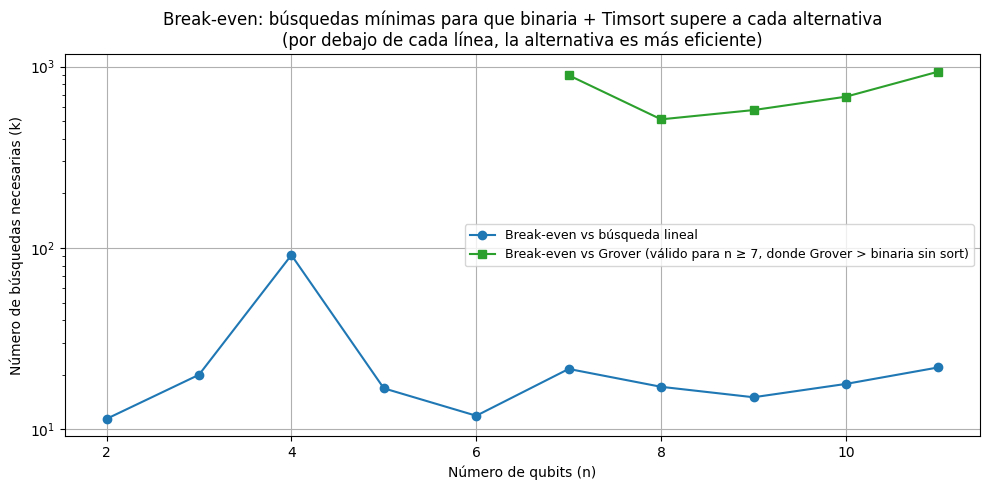

In [89]:
# Break-even formula:
#   sort + k * log2(N)  =  k * cost_per_query
#   k = sort_cost / (cost_per_query - log2(N))   where sort_cost = N * log2(N)
#
# Break-even vs Grover solo existe para n >= 7, donde Grover empieza a necesitar
# más iteraciones que consultas hace la búsqueda binaria sin sort.

breakeven_vs_linear = []
breakeven_vs_grover = []

for i in range(len(results['n_qubits'])):
    N           = results['N'][i]
    log2N       = np.log2(N)
    sort_cost   = N * log2N
    grover_cost = results['grover_iters'][i]
    linear_cost = results['linear_queries'][i]

    denom_lin = linear_cost - log2N
    breakeven_vs_linear.append(sort_cost / denom_lin if denom_lin > 0 else np.nan)

    denom_gro = grover_cost - log2N
    breakeven_vs_grover.append(sort_cost / denom_gro if denom_gro > 0 else np.nan)

plt.figure(figsize=(10, 5))
plt.plot(results['n_qubits'], breakeven_vs_linear, 'o-', color='tab:blue',
         label='Break-even vs búsqueda lineal')
plt.plot(results['n_qubits'], breakeven_vs_grover, 's-', color='tab:green',
         label='Break-even vs Grover (válido para n ≥ 7, donde Grover > binaria sin sort)')

plt.xlabel('Número de qubits (n)')
plt.ylabel('Número de búsquedas necesarias (k)')
plt.title('Break-even: búsquedas mínimas para que binaria + Timsort supere a cada alternativa\n'
          '(por debajo de cada línea, la alternativa es más eficiente)')
plt.yscale('log')
plt.legend(fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

# PLOT 3 — Probabilidad de éxito en hardware real vs n

Fracción de shots que miden el estado objetivo al ejecutar Grover en hardware IBM real. La caída refleja la acumulación de error cuántico (decoherencia y ruido de puertas) a medida que el circuito crece.

Se incluyen tres referencias:
- **Ideal**: 100% — lo que daría un hardware sin ruido.
- **Umbral de éxito** (1/√N): se considera que el algoritmo funciona si la probabilidad supera este valor. Equivale a medir el objetivo √N veces más a menudo que una distribución aleatoria uniforme.
- **Aleatoria** (1/N): baseline de adivinar al azar.

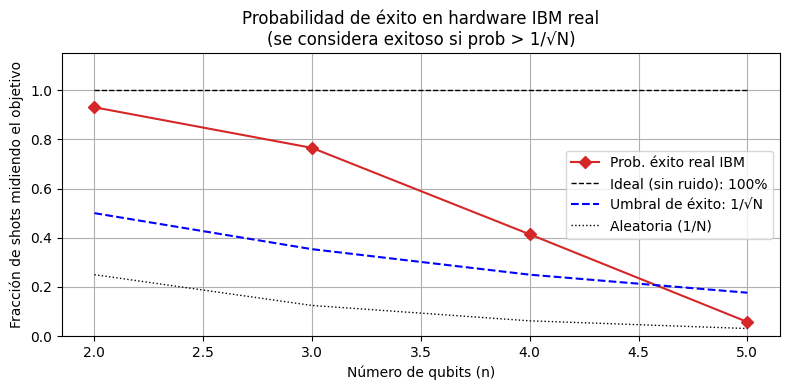

In [90]:
real_idx        = [i for i in range(len(results['n_qubits'])) if results['grover_real_ran'][i]]
real_n          = [results['n_qubits'][i]          for i in real_idx]
real_prob       = [results['grover_real_prob'][i]   for i in real_idx]
random_baseline = [1 / results['N'][i]              for i in real_idx]
threshold       = [1 / np.sqrt(results['N'][i])     for i in real_idx]

plt.figure(figsize=(8, 4))
plt.plot(real_n, real_prob,             'D-',  color='tab:red',    label='Prob. éxito real IBM')
plt.plot(real_n, [1.0] * len(real_n),  'k--', linewidth=1,        label='Ideal (sin ruido): 100%')
plt.plot(real_n, threshold,             'b--', linewidth=1.5,      label='Umbral de éxito: 1/√N')
plt.plot(real_n, random_baseline,       'k:',  linewidth=1,        label='Aleatoria (1/N)')

plt.xlabel('Número de qubits (n)')
plt.ylabel('Fracción de shots midiendo el objetivo')
plt.title('Probabilidad de éxito en hardware IBM real\n(se considera exitoso si prob > 1/√N)')
plt.ylim(0, 1.15)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PLOT 4 — Profundidad del circuito transpilado vs n

La profundidad del circuito (número de capas de puertas secuenciales) crece rápidamente con n porque las puertas MCX se descomponen en O(n²) CNOTs. A mayor profundidad, más tiempo pasan los qubits en superposición y mayor es el error acumulado — lo que explica directamente la caída observada en el Plot 3.

Se muestran dos líneas para n ≤ 5:
- **Simulación (AerSimulator)**: transpilación sin restricciones de conectividad física.
- **Hardware real IBM**: el transpilador debe enrutar el circuito a la topología del procesador, añadiendo puertas SWAP extra → profundidad mayor.

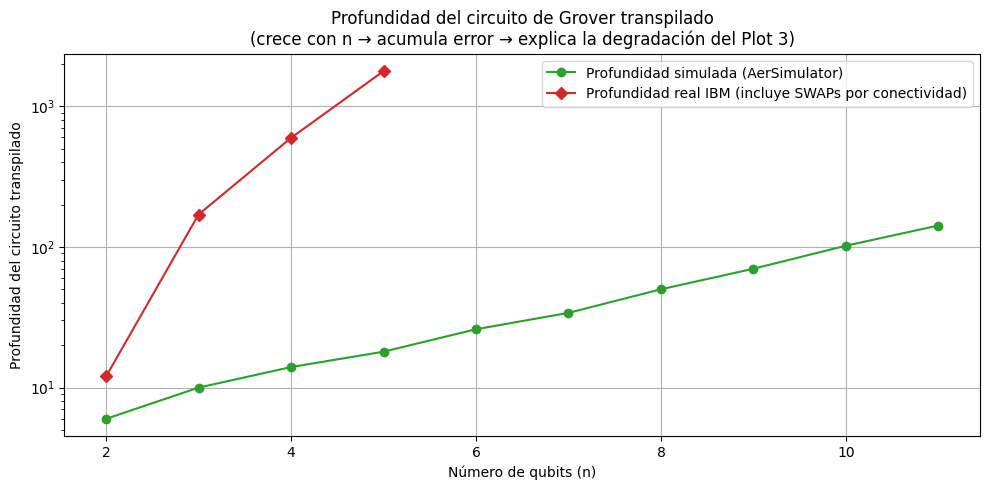

In [91]:
real_idx    = [i for i in range(len(results['n_qubits'])) if results['grover_real_ran'][i]]
real_n      = [results['n_qubits'][i]          for i in real_idx]
real_depth  = [results['circuit_depth_real'][i] for i in real_idx]

plt.figure(figsize=(10, 5))
plt.plot(results['n_qubits'], results['circuit_depth_sim'], 'o-', color='tab:green',
         label='Profundidad simulada (AerSimulator)')
plt.plot(real_n, real_depth, 'D-', color='tab:red',
         label='Profundidad real IBM (incluye SWAPs por conectividad)')

plt.xlabel('Número de qubits (n)')
plt.ylabel('Profundidad del circuito transpilado')
plt.title('Profundidad del circuito de Grover transpilado\n(crece con n → acumula error → explica la degradación del Plot 3)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# PRINT SUMMARY

In [92]:
print(f"\n{'n':>4} {'N':>6} {'Linear':>8} {'Binary':>8} {'Grover':>8} {'Sim OK':>7} "
      f"{'Depth sim':>10} {'Depth real':>11} {'Prob real':>10} {'Umbral':>8} {'Real OK':>8}")
print("-" * 93)
for i in range(len(results['n_qubits'])):
    ran         = results['grover_real_ran'][i]
    N           = results['N'][i]
    threshold   = 1 / np.sqrt(N)
    prob_str    = f"{results['grover_real_prob'][i]:.1%}"  if ran else 'N/A'
    depth_r_str = f"{results['circuit_depth_real'][i]}"    if ran else 'N/A'
    real_ok_str = ('Yes' if results['grover_real_correct'][i] else 'No') if ran else 'N/A'
    print(f"{results['n_qubits'][i]:>4} "
          f"{N:>6} "
          f"{results['linear_queries'][i]:>8.1f} "
          f"{results['binary_queries'][i]:>8.1f} "
          f"{results['grover_iters'][i]:>8} "
          f"{'Yes' if results['grover_correct'][i] else 'No':>7} "
          f"{results['circuit_depth_sim'][i]:>10} "
          f"{depth_r_str:>11} "
          f"{prob_str:>10} "
          f"{threshold:>8.1%} "
          f"{real_ok_str:>8}")


   n      N   Linear   Binary   Grover  Sim OK  Depth sim  Depth real  Prob real   Umbral  Real OK
---------------------------------------------------------------------------------------------
   2      4      2.7      2.0        1     Yes          6          12      93.0%    50.0%      Yes
   3      8      4.2      3.0        2     Yes         10         170      76.5%    35.4%      Yes
   4     16      4.7      3.0        3     Yes         14         596      41.4%    25.0%      Yes
   5     32     14.5      5.0        4     Yes         18        1777       5.8%    17.7%       No
   6     64     38.3      6.0        6     Yes         26         N/A        N/A    12.5%      N/A
   7    128     48.6      5.0        8     Yes         34         N/A        N/A     8.8%      N/A
   8    256    127.3      7.0       12     Yes         50         N/A        N/A     6.2%      N/A
   9    512    315.5      5.0       17     Yes         70         N/A        N/A     4.4%      N/A
  10   1024   